In [53]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from datetime import datetime

In [48]:
# Ruta del archivo
current_path = os.getcwd()
data_src_path = os.path.join(current_path, "data_src")
data_dst_path = os.path.join(current_path, "data_dst")
file_name = "articulos_revisados.xlsx"
file_path = os.path.join(data_src_path, file_name)

In [8]:
file_path

'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_src\\articulos_revisados.xlsx'

In [ ]:
# Verificar que el archivo existe
if os.path.exists(file_path):
    # Cargar CSV
    df = pd.read_excel(file_path) #!pip install openpyxl
    print("Archivo cargado correctamente. Primeras filas:")
    # print(df.head())
else:
    print(f"Archivo no encontrado en {file_path}")

Archivo cargado correctamente. Primeras filas:


In [13]:
df.head()

,DOI,Title,Abstract,Exclusion_Criteria,Tema a tratar,Categorización,Falsos positivos,ojo con este
0,10.4018/979-8-3693-8985-0.ch011,Current advancements in AI-driven education,"With the rise of Artificial Intelligence (AI),...",NaN,Trata sobre las aplicaciones de IA de vanguard...,IA,"VR, AR, GAME, TEA",NaN
1,10.1089/g4h.2023.0240,The Impact of Virtual Reality Intervention on ...,Introduction: Autistic children may encounter ...,NaN,Trata sobre investigar la eficacia de un progr...,"VR, TEA",NaN,NaN
2,10.1007/s10758-024-09806-6,Game-Based Performance Tasks for Assessing Rep...,"In this exploratory study, we designed and val...",NaN,Trata sobre la eficacia de un programa de ejer...,"VR, GAME, TEA",NaN,NaN
3,10.1002/jdn.70000,Virtual Reality-Based Attention Prediction Mod...,"Nowadays, virtual reality (VR) has emerged as ...",NaN,"Trata sobre considerar, mediante juegos 3D, l...","VR, TEA",GAME,NaN
4,10.4018/979-8-3693-7437-5.ch009,The impact of a gamified augmented environment...,This study investigates the impact of a Gamifi...,NaN,Trata sobre el impacto de una intervención med...,"GAME, TEA",AR,NaN


In [14]:
df_backup = df.copy()

In [37]:
def expand_categorization_column(df, col_name="Categorización", sep=","):
    """
    Crea columnas binarias cat_X a partir de la columna categórica con múltiples valores.
    
    df: DataFrame
    col_name: nombre de la columna (ej. "Categorización")
    sep: separador de categorías dentro de la celda
    """

    # 1. Limpiar y separar categorías
    df[col_name] = df[col_name].fillna("")
    splitted = df[col_name].apply(lambda x: [i.strip() for i in x.split(sep) if i.strip() != ""])

    # 2. Obtener todas las categorías únicas
    unique_cats = sorted(set(cat for sublist in splitted for cat in sublist))

    # 3. Crear columnas one-hot
    for cat in unique_cats:
        # df[f"cat_{cat}"] = splitted.apply(lambda x: 1 if cat in x else 0)
        df[cat] = splitted.apply(lambda x: 1 if cat in x else 0)
    return df, unique_cats

In [38]:
df = df_backup.copy()

In [39]:
# Reemplazos en la columna
df["Categorización"] = (
    df["Categorización"]
    .str.replace("TEA", "ASD", regex=False)
    .str.replace("IA", "AI", regex=False)
)

In [40]:
df, unique_cats = expand_categorization_column(df)

In [41]:
unique_cats

['AI', 'AR', 'ASD', 'GAME', 'VR']

In [42]:
df.head()

,DOI,Title,Abstract,Exclusion_Criteria,Tema a tratar,Categorización,Falsos positivos,ojo con este,AI,AR,ASD,GAME,VR
0,10.4018/979-8-3693-8985-0.ch011,Current advancements in AI-driven education,"With the rise of Artificial Intelligence (AI),...",NaN,Trata sobre las aplicaciones de IA de vanguard...,AI,"VR, AR, GAME, TEA",NaN,1,0,0,0,0
1,10.1089/g4h.2023.0240,The Impact of Virtual Reality Intervention on ...,Introduction: Autistic children may encounter ...,NaN,Trata sobre investigar la eficacia de un progr...,"VR, ASD",NaN,NaN,0,0,1,0,1
2,10.1007/s10758-024-09806-6,Game-Based Performance Tasks for Assessing Rep...,"In this exploratory study, we designed and val...",NaN,Trata sobre la eficacia de un programa de ejer...,"VR, GAME, ASD",NaN,NaN,0,0,1,1,1
3,10.1002/jdn.70000,Virtual Reality-Based Attention Prediction Mod...,"Nowadays, virtual reality (VR) has emerged as ...",NaN,"Trata sobre considerar, mediante juegos 3D, l...","VR, ASD",GAME,NaN,0,0,1,0,1
4,10.4018/979-8-3693-7437-5.ch009,The impact of a gamified augmented environment...,This study investigates the impact of a Gamifi...,NaN,Trata sobre el impacto de una intervención med...,"GAME, ASD",AR,NaN,0,0,1,1,0


In [43]:
cols = unique_cats.copy()

In [44]:
cols.append("DOI")
cols.append("Title")
cols.append("Categorización")

In [45]:
cols

['AI', 'AR', 'ASD', 'GAME', 'VR', 'DOI', 'Title', 'Categorización']

In [46]:
df_cats = df[cols].copy()

In [47]:
df_cats.head()

,AI,AR,ASD,GAME,VR,DOI,Title,Categorización
0,1,0,0,0,0,10.4018/979-8-3693-8985-0.ch011,Current advancements in AI-driven education,AI
1,0,0,1,0,1,10.1089/g4h.2023.0240,The Impact of Virtual Reality Intervention on ...,"VR, ASD"
2,0,0,1,1,1,10.1007/s10758-024-09806-6,Game-Based Performance Tasks for Assessing Rep...,"VR, GAME, ASD"
3,0,0,1,0,1,10.1002/jdn.70000,Virtual Reality-Based Attention Prediction Mod...,"VR, ASD"
4,0,0,1,1,0,10.4018/979-8-3693-7437-5.ch009,The impact of a gamified augmented environment...,"GAME, ASD"


In [54]:
def _ensure_output_dir(data_dst_path):
    os.makedirs(data_dst_path, exist_ok=True)


def _get_timestamp():
    return datetime.now().strftime("%Y%m%d_%H%M%S")


def _save_and_show_plot(fig, data_dst_path, filename_base):
    _ensure_output_dir(data_dst_path)

    timestamp = _get_timestamp()

    png_path = os.path.join(data_dst_path, f"{filename_base}_{timestamp}.png")
    pdf_path = os.path.join(data_dst_path, f"{filename_base}_{timestamp}.pdf")

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()   # 👈 ahora sí se muestra
    plt.close(fig)

    return png_path, pdf_path


# =========================
# (i) BARPLOT
# =========================
def plot_bar_ar_vr(df, data_dst_path):
    counts = df[["AR", "VR"]].sum()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(counts.index, counts.values)
    ax.set_xlabel("Category")
    ax.set_ylabel("Count")
    ax.set_title("AR and VR counts")
    ax.grid(axis="y", alpha=0.3)

    return _save_and_show_plot(fig, data_dst_path, "barplot_AR_VR")


# =========================
# GENERIC BUBBLE
# =========================
def plot_bubble_pair(df, x_col, y_col, data_dst_path, filename_base=None):

    if filename_base is None:
        filename_base = f"bubble_{x_col}_vs_{y_col}"

    counts = (
        df.groupby([x_col, y_col])
        .size()
        .reset_index(name="count")
    )

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.scatter(
        counts[x_col],
        counts[y_col],
        s=counts["count"] * 80,
        alpha=0.6
    )

    for _, row in counts.iterrows():
        ax.text(
            row[x_col],
            row[y_col],
            str(row["count"]),
            ha="center",
            va="center",
            fontsize=10
        )

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col}")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.grid(alpha=0.3)

    return _save_and_show_plot(fig, data_dst_path, filename_base)


# =========================
# (ii)–(vi) ESPECÍFICAS
# =========================
def plot_bubble_ar_game(df, data_dst_path):
    return plot_bubble_pair(df, "AR", "GAME", data_dst_path, "bubble_AR_vs_GAME")


def plot_bubble_vr_game(df, data_dst_path):
    return plot_bubble_pair(df, "VR", "GAME", data_dst_path, "bubble_VR_vs_GAME")


def plot_bubble_vr_asd(df, data_dst_path):
    return plot_bubble_pair(df, "VR", "ASD", data_dst_path, "bubble_VR_vs_ASD")


def plot_bubble_ar_asd(df, data_dst_path):
    return plot_bubble_pair(df, "AR", "ASD", data_dst_path, "bubble_AR_vs_ASD")


def plot_bubble_asd_game(df, data_dst_path):
    return plot_bubble_pair(df, "ASD", "GAME", data_dst_path, "bubble_ASD_vs_GAME")

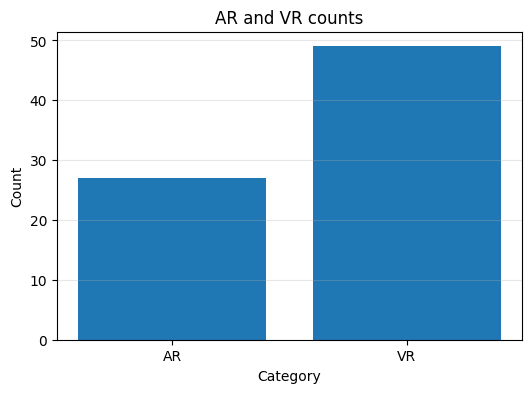

('c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\barplot_AR_VR_20260525_112845.png',
 'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\barplot_AR_VR_20260525_112845.pdf')

In [55]:
plot_bar_ar_vr(df_cats, data_dst_path)

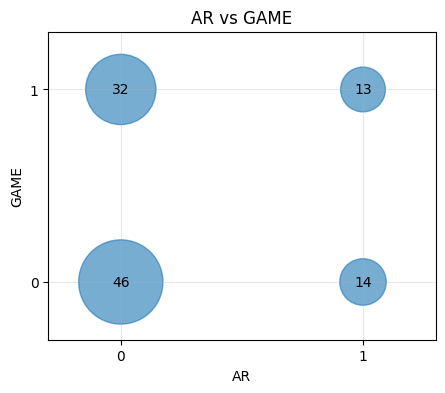

('c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_AR_vs_GAME_20260525_112915.png',
 'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_AR_vs_GAME_20260525_112915.pdf')

In [57]:
plot_bubble_ar_game(df_cats, data_dst_path)

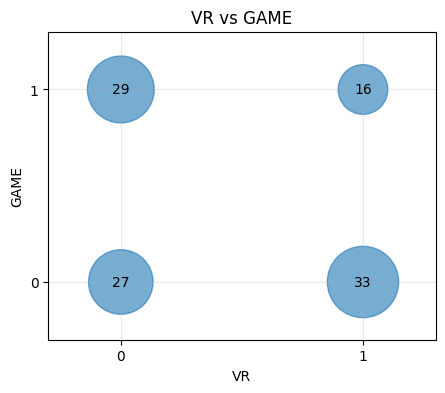

('c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_VR_vs_GAME_20260525_112848.png',
 'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_VR_vs_GAME_20260525_112848.pdf')

In [56]:
plot_bubble_vr_game(df_cats, data_dst_path)

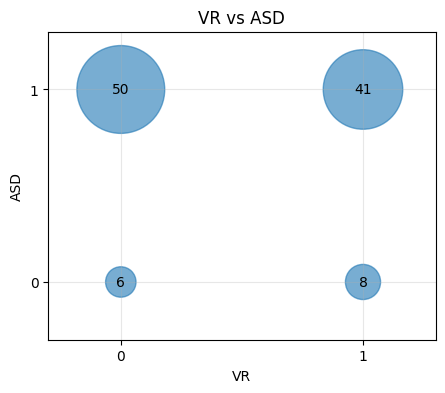

('c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_VR_vs_ASD_20260525_112942.png',
 'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_VR_vs_ASD_20260525_112942.pdf')

In [58]:
plot_bubble_vr_asd(df_cats, data_dst_path)

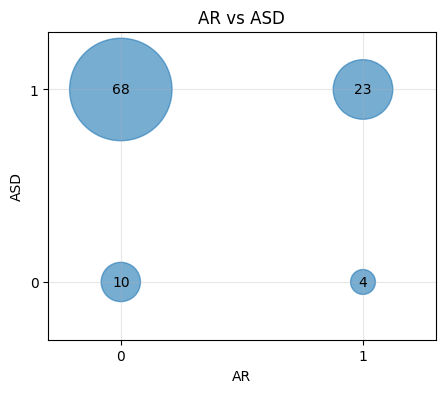

('c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_AR_vs_ASD_20260525_112944.png',
 'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_AR_vs_ASD_20260525_112944.pdf')

In [59]:
plot_bubble_ar_asd(df_cats, data_dst_path)

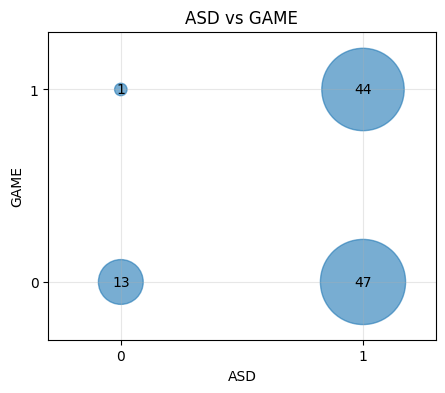

('c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_ASD_vs_GAME_20260525_112946.png',
 'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_ASD_vs_GAME_20260525_112946.pdf')

In [60]:
plot_bubble_asd_game(df_cats, data_dst_path)

In [61]:
def add_xr_column(df):
    """
    Crea la columna XR:
    - AR si AR == 1
    - VR si VR == 1
    - AR+VR si ambas son 1
    - None si ninguna es 1
    """

    df = df.copy()

    def get_xr(row):
        if row["AR"] == 1 and row["VR"] == 1:
            return "AR+VR"
        elif row["AR"] == 1:
            return "AR"
        elif row["VR"] == 1:
            return "VR"
        else:
            return "None"

    df["XR"] = df.apply(get_xr, axis=1)

    return df

In [62]:
def plot_bubble_pair_categorical(df, x_col, y_col, data_dst_path, filename_base=None):

    if filename_base is None:
        filename_base = f"bubble_{x_col}_vs_{y_col}"

    counts = (
        df.groupby([x_col, y_col])
        .size()
        .reset_index(name="count")
    )

    x_values = sorted(df[x_col].dropna().unique())
    y_values = sorted(df[y_col].dropna().unique())

    x_map = {v: i for i, v in enumerate(x_values)}
    y_map = {v: i for i, v in enumerate(y_values)}

    counts["x_pos"] = counts[x_col].map(x_map)
    counts["y_pos"] = counts[y_col].map(y_map)

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.scatter(
        counts["x_pos"],
        counts["y_pos"],
        s=counts["count"] * 80,
        alpha=0.6
    )

    for _, row in counts.iterrows():
        ax.text(
            row["x_pos"],
            row["y_pos"],
            str(row["count"]),
            ha="center",
            va="center",
            fontsize=10
        )

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col}")

    ax.set_xticks(list(x_map.values()))
    ax.set_xticklabels(list(x_map.keys()))

    ax.set_yticks(list(y_map.values()))
    ax.set_yticklabels(list(y_map.keys()))

    ax.grid(alpha=0.3)

    return _save_and_show_plot(fig, data_dst_path, filename_base)

In [63]:
def plot_bubble_xr_game(df, data_dst_path):
    return plot_bubble_pair_categorical(
        df,
        x_col="XR",
        y_col="GAME",
        data_dst_path=data_dst_path,
        filename_base="bubble_XR_vs_GAME"
    )


def plot_bubble_xr_asd(df, data_dst_path):
    return plot_bubble_pair_categorical(
        df,
        x_col="XR",
        y_col="ASD",
        data_dst_path=data_dst_path,
        filename_base="bubble_XR_vs_ASD"
    )

In [64]:
df_cat_backyp = df_cats.copy()

In [65]:
df_cats = add_xr_column(df_cats)

In [66]:
df_cats

,AI,AR,ASD,GAME,VR,DOI,Title,Categorización,XR
0,1,0,0,0,0,10.4018/979-8-3693-8985-0.ch011,Current advancements in AI-driven education,AI,None
1,0,0,1,0,1,10.1089/g4h.2023.0240,The Impact of Virtual Reality Intervention on ...,"VR, ASD",VR
2,0,0,1,1,1,10.1007/s10758-024-09806-6,Game-Based Performance Tasks for Assessing Rep...,"VR, GAME, ASD",VR
3,0,0,1,0,1,10.1002/jdn.70000,Virtual Reality-Based Attention Prediction Mod...,"VR, ASD",VR
4,0,0,1,1,0,10.4018/979-8-3693-7437-5.ch009,The impact of a gamified augmented environment...,"GAME, ASD",None
...,...,...,...,...,...,...,...,...,...
100,0,0,1,0,0,10.1145/3340631.3394867,Recommending Video Games to Adults with Autism...,ASD,None
101,0,0,1,0,0,10.1145/3383923.3383954,Validation of Emotions as a Measure of Selecti...,ASD,None
102,0,0,1,0,0,10.1145/3459608,C-Hg: A Collaborative Haptic-Gripper Fine Moto...,ASD,None
103,0,0,1,1,0,10.1145/3429630.3429635,Recognizing Situational Color and Facial Emoti...,"GAME, ASD",None


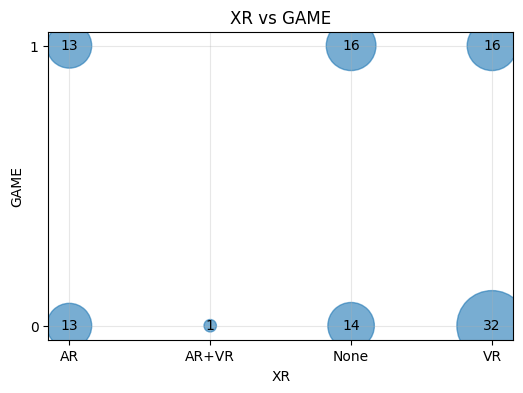

('c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_XR_vs_GAME_20260525_113327.png',
 'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_XR_vs_GAME_20260525_113327.pdf')

In [67]:
plot_bubble_xr_game(df_cats, data_dst_path)

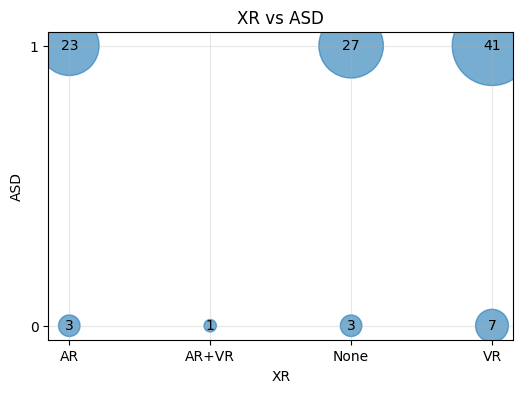

('c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_XR_vs_ASD_20260525_113335.png',
 'c:\\Users\\alvar\\repos\\GitHub\\SMS_ASD\\data_dst\\bubble_XR_vs_ASD_20260525_113335.pdf')

In [68]:
plot_bubble_xr_asd(df_cats, data_dst_path)